In [1]:
#노트북이 코랩에서 실행 중인지 체크합니다.

import sys
if 'google.colab' in sys.modules:
  !echo 'debconf debconf/frontend select Noniteractive' | \
  debconf-set-selections

  # 나눔 폰트를 설치합니다.
  !sudo apt-get -qq -y install fonts-nanum
  import matplotlib.font_manager as fm
  font_files = fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum'])
  for fpath in font_files:
    fm.fontManager.addfont(fpath)

In [2]:
import matplotlib.pyplot as plt
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['figure.dpi']=100

In [3]:
# 1. 필요한 라이브러리 설치 (한 번만 실행)
!pip install konlpy wordcloud matplotlib

# 2. 폰트 설정 (나눔고딕 등 한글 폰트가 있다면 경로를 맞게 수정)
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc
import matplotlib
import os

# Colab에 나눔고딕 폰트 설치 예시 (없으면 주석 처리해도 됨)
!apt-get -y install fonts-nanum
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
font = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font)
matplotlib.rcParams['axes.unicode_minus'] = False

# 3. 텍스트 파일 불러오기
# history_text.txt, social_text.txt를 Colab 왼쪽 '파일' 영역에 미리 업로드해 둔다.
with open("history_text.txt", "r", encoding="utf-8") as f:
    history_text = f.read()

with open("social_text.txt", "r", encoding="utf-8") as f:
    social_text = f.read()


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.


In [8]:
from konlpy.tag import Okt
from collections import Counter

okt = Okt()

# 불용어(분석에서 제외할 단어들) 예시
stopwords = ["그", "이", "저", "것", "있다", "하다", "그리고", "그러나", "위해", "통해", "등", "에서", "으로", "이다", "우리", "이후", "수립", "전개", "나라", "활동", "지역", "과정", "자료"]

def get_noun_frequencies(text):
    nouns = okt.nouns(text)  # 명사만 추출
    # 한 글자짜리 명사 제거 + 불용어 제거
    filtered = [n for n in nouns if len(n) > 1 and n not in stopwords]
    counts = Counter(filtered)
    return counts

history_freq = get_noun_frequencies(history_text)
social_freq = get_noun_frequencies(social_text)

# 상위 30개 단어 확인
print("=== 역사 교과서 상위 단어 ===")
for word, cnt in history_freq.most_common(30):
    print(word, cnt)

print("\n=== 사회 교과서 상위 단어 ===")
for word, cnt in social_freq.most_common(30):
    print(word, cnt)


=== 역사 교과서 상위 단어 ===
운동 134
일본 90
고구려 75
정부 69
백제 68
신라 63
민족 58
중국 57
조선 50
개혁 47
세기 43
국가 41
전쟁 41
세력 39
영토 37
대한 37
추진 34
독립 34
개항 33
영국 30
대한민국 30
조약 29
정책 28
혁명 28
한강 27
내용 27
일제 27
모습 26
농민 26
임시 25

=== 사회 교과서 상위 단어 ===
우리나라 68
독도 65
산업 50
세계 43
남부 40
통일 35
영남 34
국가 34
국토 32
호남 31
지리 30
축제 27
영토 25
공업 23
영해 22
경제 21
표시 21
경쟁력 20
지도 19
영역 19
발달 18
가치 17
단지 17
노력 16
변화 15
바다 15
울릉도 15
여러 15
특성 14
매력 14


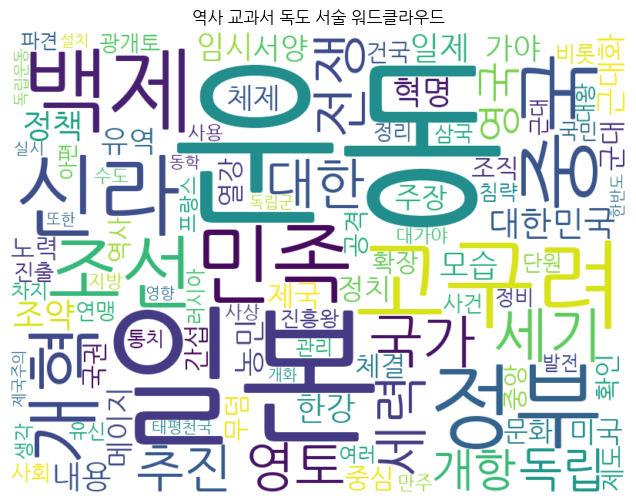

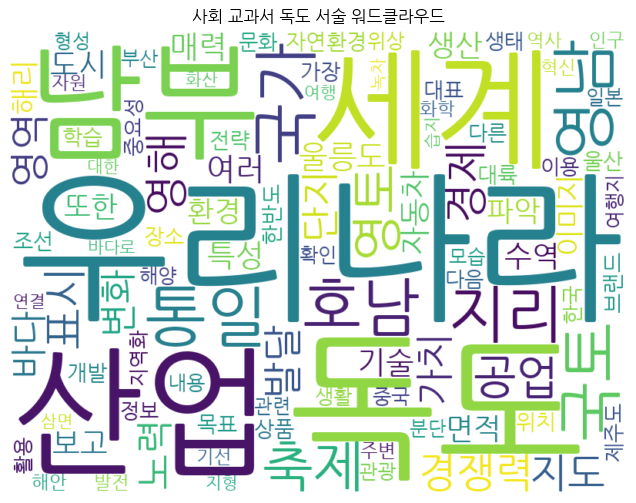

In [9]:
from wordcloud import WordCloud

def show_wordcloud(freq_dict, title):
    wc = WordCloud(font_path=font_path,
                   background_color="white",
                   width=800, height=600)
    wc = wc.generate_from_frequencies(freq_dict)

    plt.figure(figsize=(8, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.show()

# 딕셔너리 형태로 변환
history_dict = dict(history_freq.most_common(100))
social_dict = dict(social_freq.most_common(100))

show_wordcloud(history_dict, "역사 교과서 독도 서술 워드클라우드")
show_wordcloud(social_dict, "사회 교과서 독도 서술 워드클라우드")


In [10]:
import pandas as pd

top_n = 30

hist_top = history_freq.most_common(top_n)
soc_top = social_freq.most_common(top_n)

df_hist = pd.DataFrame(hist_top, columns=["단어_역사", "빈도_역사"])
df_soc = pd.DataFrame(soc_top, columns=["단어_사회", "빈도_사회"])

# 인덱스를 기준으로 좌우로 붙이기
df_compare = pd.concat([df_hist, df_soc], axis=1)
df_compare


,단어_역사,빈도_역사,단어_사회,빈도_사회
0,운동,134,우리나라,68
1,일본,90,독도,65
2,고구려,75,산업,50
3,정부,69,세계,43
4,백제,68,남부,40
5,신라,63,통일,35
6,민족,58,영남,34
7,중국,57,국가,34
8,조선,50,국토,32
9,개혁,47,호남,31


In [11]:
def preprocess_text(text):
    # 특수문자 제거, 공백 정리
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def get_nouns(text, min_len=2):
    text = preprocess_text(text)
    nouns = okt.nouns(text)
    filtered = [n for n in nouns if len(n) >= min_len and n not in stopwords]
    return filtered

=== 역사 교과서 상위 15개 키워드 ===
운동         134
일본          90
고구려         75
정부          69
백제          68
신라          63
민족          58
중국          57
조선          50
개혁          47
세기          43
국가          41
전쟁          41
세력          39
영토          37

=== 사회 교과서 상위 15개 키워드 ===
우리나라        68
독도          65
산업          50
세계          43
남부          40
통일          35
영남          34
국가          34
국토          32
호남          31
지리          30
축제          27
영토          25
공업          23
영해          22


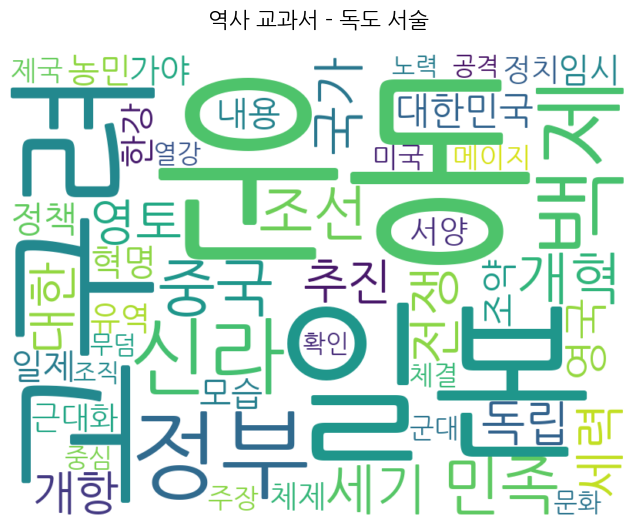

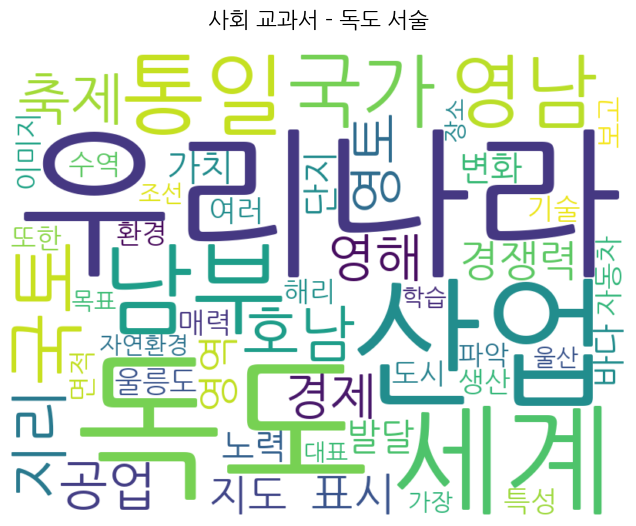

In [12]:
import re # Add this line

# Redefine preprocess_text and get_nouns to ensure 're' is in scope
def preprocess_text(text):
    # 특수문자 제거, 공백 정리
    text = re.sub(r'[^가-힣0-9a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def get_nouns(text, min_len=2):
    text = preprocess_text(text)
    nouns = okt.nouns(text)
    filtered = [n for n in nouns if len(n) >= min_len and n not in stopwords]
    return filtered

# 빈도 분석
history_nouns = get_nouns(history_text)
social_nouns = get_nouns(social_text)

history_freq = Counter(history_nouns)
social_freq = Counter(social_nouns)

print("=== 역사 교과서 상위 15개 키워드 ===")
for word, cnt in history_freq.most_common(15):
    print(f"{word:10s} {cnt:3d}")

print("\n=== 사회 교과서 상위 15개 키워드 ===")
for word, cnt in social_freq.most_common(15):
    print(f"{word:10s} {cnt:3d}")

# 워드클라우드
from wordcloud import WordCloud

def show_wordcloud(freq, title):
    wc = WordCloud(font_path=font_path, background_color="white",
                   width=800, height=600, max_words=100)
    wc = wc.generate_from_frequencies(freq)

    plt.figure(figsize=(10, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title, fontsize=16, pad=20)
    plt.show()

show_wordcloud(dict(history_freq.most_common(50)), "역사 교과서 - 독도 서술")
show_wordcloud(dict(social_freq.most_common(50)), "사회 교과서 - 독도 서술")

In [13]:
!pip install pyvis

# 공동출현 네트워크 (상위 키워드 20개 기준으로 주변 5개 단어와 연결)
def build_cooccurrence_network(nouns, top_n=15, window=10):
    top_words = [w for w, _ in Counter(nouns).most_common(top_n)]
    word_to_idx = {w: i for i, w in enumerate(top_words)}

    # 인접 행렬 (공동출현 횟수)
    co_matrix = np.zeros((len(top_words), len(top_words)))

    for i in range(len(nouns)):
        if nouns[i] in word_to_idx:
            center_idx = word_to_idx[nouns[i]]
            # 좌우 window 크기만큼 확인
            for j in range(max(0, i-window), min(len(nouns), i+window+1)):
                if i != j and nouns[j] in word_to_idx:
                    neighbor_idx = word_to_idx[nouns[j]]
                    co_matrix[center_idx, neighbor_idx] += 1
                    co_matrix[neighbor_idx, center_idx] += 1

    return top_words, co_matrix

import numpy as np
import networkx as nx
from pyvis.network import Network

# 네트워크 생성
hist_words, hist_matrix = build_cooccurrence_network(history_nouns)
soc_words, soc_matrix = build_cooccurrence_network(social_nouns)

def draw_network(words, matrix, title):
    G = nx.from_numpy_array(matrix)
    G = nx.relabel_nodes(G, {i: words[i] for i in range(len(words))})

    # 중심성 계산해서 노드 크기 조정
    centrality = nx.degree_centrality(G)

    net = Network(height="500px", width="100%", notebook=True, directed=False)
    net.from_nx(G)

    # 노드 크기, 색상 조정
    for node in net.nodes:
        node['size'] = centrality[node['id']] * 50 + 10
        node['color'] = 'lightblue'

    net.set_options("""
    var options = {
      "physics": {
        "forceAtlas2Based": {
          "springLength": 100,
          "avoidOverlap": 0.5
        }
      }
    }
    """)

    net.show(f"{title.replace(' ', '_')}.html")
    print(f"📊 {title} 네트워크 저장 완료!")

draw_network(hist_words, hist_matrix, "역사 교과서 공동출현 네트워크")
draw_network(soc_words, soc_matrix, "사회 교과서 공동출현 네트워크")

역사_교과서_공동출현_네트워크.html
📊 역사 교과서 공동출현 네트워크 네트워크 저장 완료!
사회_교과서_공동출현_네트워크.html
📊 사회 교과서 공동출현 네트워크 네트워크 저장 완료!


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
📋 사용 가능한 나눔 폰트: ['NanumMyeongjo', 'NanumGothic', 'NanumGothicCoding']
✅ /usr/share/fonts/truetype/nanum/NanumGothic.ttf 폰트 로드 성공!


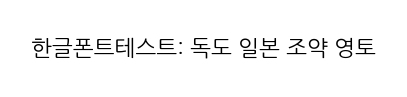

✅ 폰트 테스트 완료!
🎯 역사 교과서 공동출현 네트워크
📊 분석 대상 상위 20개 키워드:
 1. 운동         (134회)
 2. 일본         ( 90회)
 3. 고구려        ( 75회)
 4. 정부         ( 69회)
 5. 백제         ( 68회)
 6. 신라         ( 63회)
 7. 민족         ( 58회)
 8. 중국         ( 57회)
 9. 조선         ( 50회)
10. 개혁         ( 47회)
11. 세기         ( 43회)
12. 국가         ( 41회)
13. 전쟁         ( 41회)
14. 세력         ( 39회)
15. 영토         ( 37회)
16. 대한         ( 37회)
17. 추진         ( 34회)
18. 독립         ( 34회)
19. 개항         ( 33회)
20. 영국         ( 30회)

🔄 공동출현 행렬 계산 중...
✅ 네트워크 행렬 생성 완료!


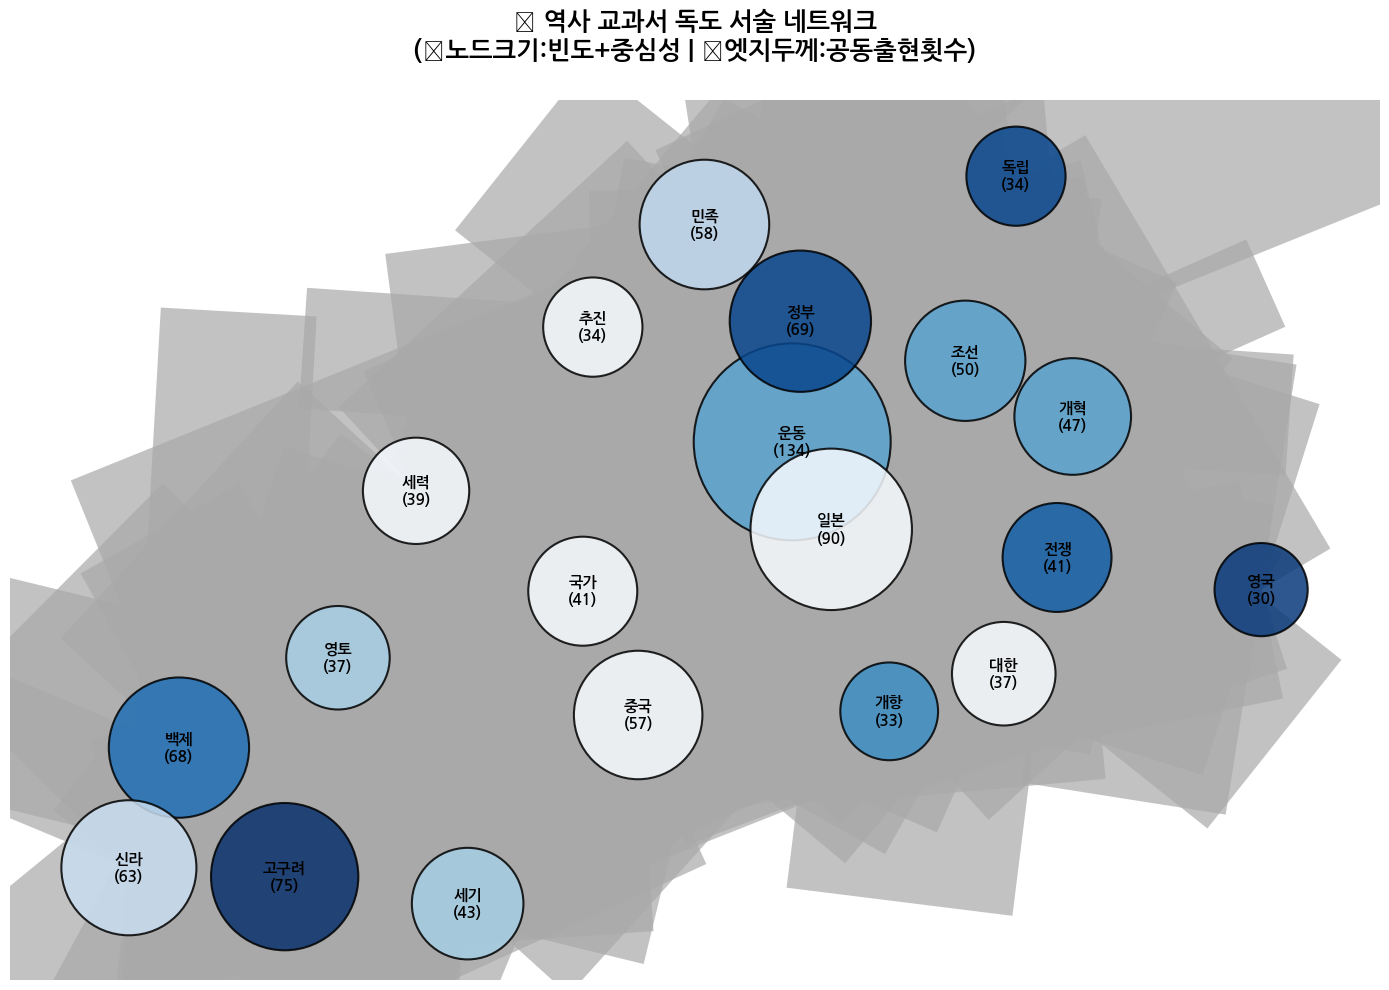


📊 📚 역사 교과서 독도 서술 네트워크 중심 키워드 TOP 10


,순위,키워드,중심성,연결수,빈도
0,12,국가,0.009,19,41
1,17,추진,0.009,19,34
2,16,대한,0.009,19,37
3,8,중국,0.009,19,57
4,14,세력,0.009,19,39
5,2,일본,0.009,19,90
6,6,신라,0.007,18,63
7,7,민족,0.007,18,58
8,11,세기,0.006,17,43
9,15,영토,0.006,17,37



🎯 사회 교과서 공동출현 네트워크
📊 분석 대상 상위 20개 키워드:
 1. 우리나라       ( 68회)
 2. 독도         ( 65회)
 3. 산업         ( 50회)
 4. 세계         ( 43회)
 5. 남부         ( 40회)
 6. 통일         ( 35회)
 7. 영남         ( 34회)
 8. 국가         ( 34회)
 9. 국토         ( 32회)
10. 호남         ( 31회)
11. 지리         ( 30회)
12. 축제         ( 27회)
13. 영토         ( 25회)
14. 공업         ( 23회)
15. 영해         ( 22회)
16. 경제         ( 21회)
17. 표시         ( 21회)
18. 경쟁력        ( 20회)
19. 지도         ( 19회)
20. 영역         ( 19회)

🔄 공동출현 행렬 계산 중...
✅ 네트워크 행렬 생성 완료!


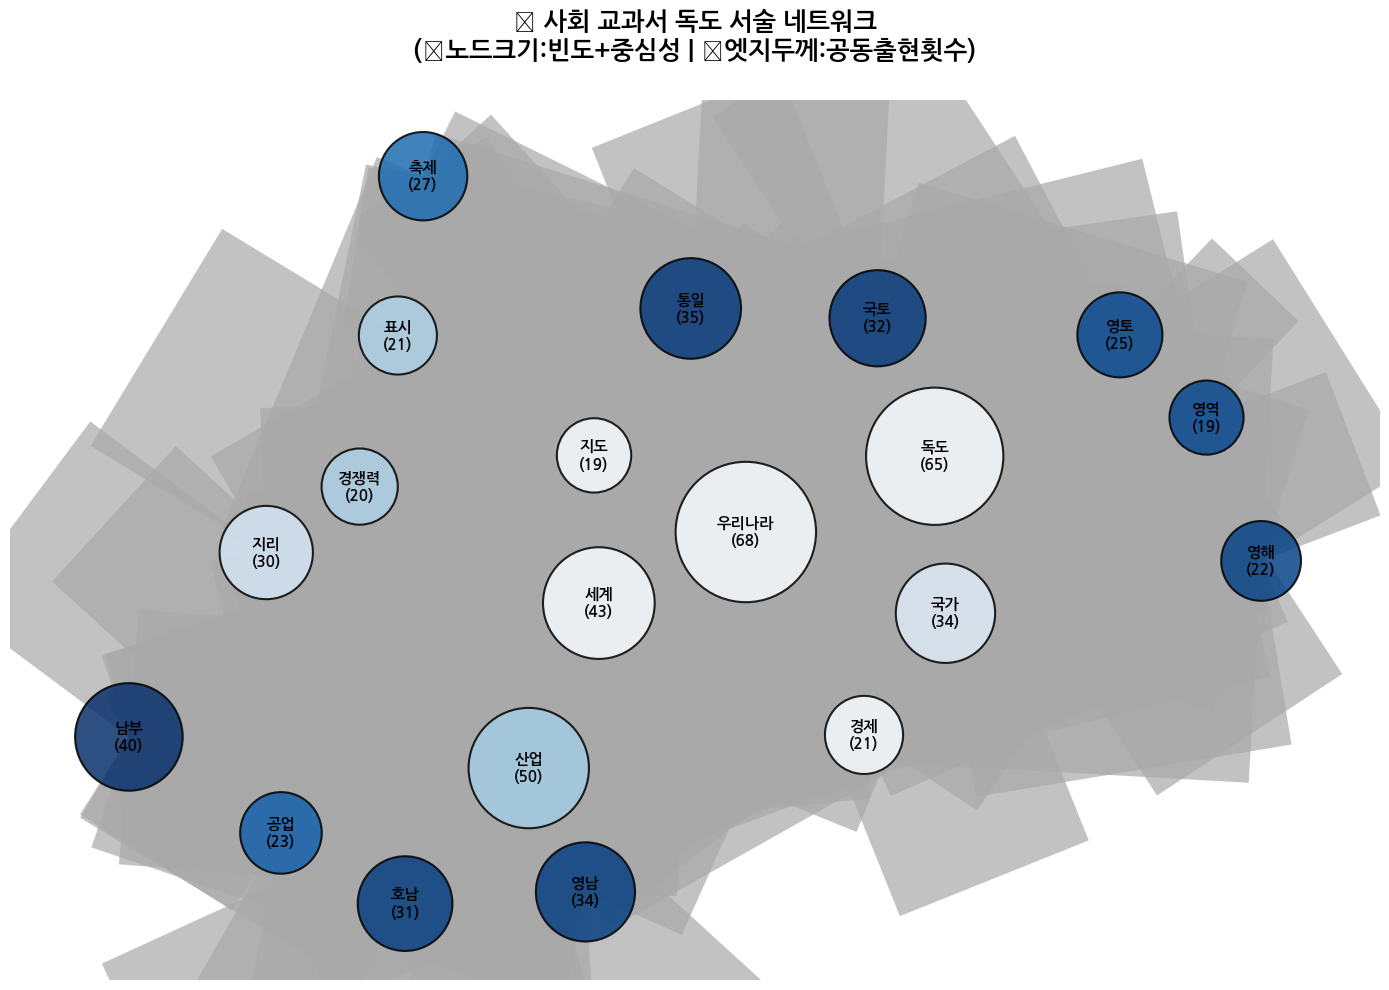


📊 🌍 사회 교과서 독도 서술 네트워크 중심 키워드 TOP 10


,순위,키워드,중심성,연결수,빈도
0,1,우리나라,0.018,19,68
1,19,지도,0.018,19,19
2,4,세계,0.018,19,43
3,16,경제,0.018,19,21
4,2,독도,0.018,19,65
5,8,국가,0.015,18,34
6,11,지리,0.015,18,30
7,17,표시,0.012,18,21
8,18,경쟁력,0.012,18,20
9,3,산업,0.011,17,50



🔥 역사 vs 사회 교과서 중심 키워드 비교 (상위 10위)


,순위,역사_중심키워드,역사_중심성,사회_중심키워드,사회_중심성
0,1,국가,0.009,우리나라,0.018
1,2,추진,0.009,지도,0.018
2,3,대한,0.009,세계,0.018
3,4,중국,0.009,경제,0.018
4,5,세력,0.009,독도,0.018
5,6,일본,0.009,국가,0.015
6,7,신라,0.007,지리,0.015
7,8,민족,0.007,표시,0.012
8,9,세기,0.006,경쟁력,0.012
9,10,영토,0.006,산업,0.011


In [17]:
# 🌐 ② 완성형 공동출현 네트워크 (한글 폰트 완벽 해결 + Colab 내 출력)
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter, defaultdict
from matplotlib import font_manager

# 🔥 1. 폰트 완벽 설정 (Colab 최적화)
import matplotlib as mpl
import warnings
warnings.filterwarnings('ignore')

# 나눔고딕 폰트 설치 및 로드
!apt-get update -qq
!apt-get install -y fonts-nanum > /dev/null

# 폰트 캐시 새로고침
# font_manager._rebuild() # 이 줄을 제거합니다.

# 사용 가능한 한글 폰트 확인
font_list = [f.name for f in font_manager.fontManager.ttflist]
nanum_fonts = [f for f in font_list if 'Nanum' in f]
print("📋 사용 가능한 나눔 폰트:", nanum_fonts[:3])  # 처음 3개만 출력

# 폰트 경로 직접 지정 (가장 안정적)
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
if os.path.exists(font_path):
    prop = font_manager.FontProperties(fname=font_path)
    plt.rcParams['font.family'] = prop.get_name()
    plt.rcParams['axes.unicode_minus'] = False
    print(f"✅ {font_path} 폰트 로드 성공!")
else:
    plt.rcParams['font.family'] = 'DejaVu Sans'  # 백업 폰트
    print("⚠️ 나눔 폰트 없음, 기본 폰트 사용")

# 테스트 플롯 (폰트 정상 작동 확인)
plt.figure(figsize=(5,1))
plt.text(0.5, 0.5, '한글폰트테스트: 독도 일본 조약 영토', ha='center', va='center', fontsize=16)
plt.axis('off')
plt.show()
print("✅ 폰트 테스트 완료!")

# 기존 함수들 (폰트 설정만 수정)
def build_full_cooccurrence_network(nouns, top_n=20, context_window=50):
    """상위 top_n 키워드 간 전체 텍스트에서의 실제 공동출현 네트워크"""
    word_freq = Counter(nouns)
    top_words = [w for w, _ in word_freq.most_common(top_n)]
    word_to_idx = {w: i for i, w in enumerate(top_words)}

    print(f"📊 분석 대상 상위 {top_n}개 키워드:")
    for i, word in enumerate(top_words):
        print(f"{i+1:2d}. {word:10s} ({word_freq[word]:3d}회)")
    print()

    # 위치 정보 수집
    position_dict = defaultdict(list)
    for i, noun in enumerate(nouns):
        if noun in word_to_idx:
            position_dict[noun].append(i)

    # 공동출현 행렬 계산
    print("🔄 공동출현 행렬 계산 중...")
    co_matrix = np.zeros((len(top_words), len(top_words)))

    for i, word1 in enumerate(top_words):
        for j, word2 in enumerate(top_words):
            if i != j:
                pos1 = position_dict[word1]
                pos2 = position_dict[word2]

                # 문맥 창 내 공동출현 횟수
                overlap_count = sum(1 for p1 in pos1 for p2 in pos2
                                  if abs(p1 - p2) < context_window)
                co_matrix[i, j] = overlap_count
                co_matrix[j, i] = overlap_count

    print("✅ 네트워크 행렬 생성 완료!")
    return top_words, co_matrix, word_freq

def plot_network_matplotlib(words, matrix, word_freq, title, figsize=(14, 10)):
    """Matplotlib으로 네트워크 그래프 직접 출력 (한글 폰트 보장)"""

    # NetworkX 그래프 생성
    G = nx.from_numpy_array(matrix)
    G = nx.relabel_nodes(G, {i: words[i] for i in range(len(words))})

    # 연결이 있는 노드만 추출
    G = G.subgraph([n for n in G.nodes if G.degree(n) > 0]).copy()

    if len(G.nodes) == 0:
        print("⚠️ 연결된 노드가 없어서 그래프를 그릴 수 없습니다.")
        return None, None, None

    plt.figure(figsize=figsize)

    # 위치 계산 (spring layout)
    pos = nx.spring_layout(G, k=2, iterations=100, seed=42)

    # 중심성 계산
    centrality = nx.betweenness_centrality(G)

    # 노드 크기 (빈도 + 중심성)
    node_sizes = [max(300, word_freq.get(node, 1) * 150 + centrality.get(node, 0) * 800)
                  for node in G.nodes]

    # 엣지 두께 (최소 1 이상 보장)
    edge_weights = [max(1, G[u][v]['weight'] * 4) for u, v in G.edges()]

    # 네트워크 그리기
    nx.draw_networkx_nodes(G, pos,
                          node_size=node_sizes,
                          node_color=[centrality.get(node, 0) for node in G.nodes],
                          cmap=plt.cm.Blues_r,  # 색상 반전으로 더 선명하게
                          alpha=0.85,
                          edgecolors='black',
                          linewidths=1.5)

    nx.draw_networkx_edges(G, pos,
                          width=edge_weights,
                          alpha=0.7,
                          edge_color='darkgray',
                          arrows=False,
                          arrowstyle='->',
                          arrowsize=0)

    # 라벨 (폰트 크기 최적화)
    labels = {}
    for node in G.nodes:
        freq = word_freq.get(node, 0)
        labels[node] = f"{node}\n({freq})"

    nx.draw_networkx_labels(G, pos, labels,
                          font_size=11,
                          font_weight='bold',
                          font_family=plt.rcParams['font.family'])

    plt.title(f"{title}\n(🔵노드크기:빈도+중심성 | ⚡엣지두께:공동출현횟수)",
              fontsize=18, pad=30, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # 중심성 순위표 출력
    print(f"\n📊 {title} 중심 키워드 TOP 10")
    print("="*70)
    centrality_df = pd.DataFrame({
        '순위': range(1, len(centrality)+1),
        '키워드': list(centrality.keys()),
        '중심성': [f"{centrality[n]:.3f}" for n in centrality.keys()],
        '연결수': [G.degree(n) for n in centrality.keys()],
        '빈도': [word_freq.get(n, 0) for n in centrality.keys()]
    }).sort_values('중심성', ascending=False).reset_index(drop=True)

    display(centrality_df.head(10))

    return G, pos, centrality_df

# 🔥 실제 분석 실행 (history_nouns, social_nouns가 이미 정의되어 있다고 가정)
print("🎯 역사 교과서 공동출현 네트워크")
hist_words, hist_matrix, hist_freq = build_full_cooccurrence_network(history_nouns, top_n=20)
hist_G, hist_pos, hist_df = plot_network_matplotlib(hist_words, hist_matrix, hist_freq,
                                                   "📚 역사 교과서 독도 서술 네트워크")

print("\n🎯 사회 교과서 공동출현 네트워크")
soc_words, soc_matrix, soc_freq = build_full_cooccurrence_network(social_nouns, top_n=20)
soc_G, soc_pos, soc_df = plot_network_matplotlib(soc_words, soc_matrix, soc_freq,
                                                "🌍 사회 교과서 독도 서술 네트워크")

# 📊 최종 비교표
if hist_df is not None and soc_df is not None:
    print("\n" + "="*90)
    print("🔥 역사 vs 사회 교과서 중심 키워드 비교 (상위 10위)")
    print("="*90)

    comparison_df = pd.DataFrame({
        '순위': range(1, 11),
        '역사_중심키워드': hist_df.head(10)['키워드'].values,
        '역사_중심성': hist_df.head(10)['중심성'].values,
        '사회_중심키워드': soc_df.head(10)['키워드'].values,
        '사회_중심성': soc_df.head(10)['중심성'].values
    })
    display(comparison_df)
else:
    print("⚠️ 비교표 생성 실패 - 네트워크 데이터 확인 필요")


In [18]:
# 토픽 모델링 (LDA)
!pip install gensim pyLDAvis
from gensim import corpora
from gensim.models import LdaModel
import pyLDAvis.gensim_models

# 문서 단위로 분할 (문단별 또는 문장별)
def split_into_docs(text):
    # 문단 단위로 분할
    paragraphs = [p.strip() for p in text.split('\n') if len(p.strip()) > 20]
    docs = [get_nouns(p) for p in paragraphs if len(get_nouns(p)) > 3]
    return docs

history_docs = split_into_docs(history_text)
social_docs = split_into_docs(social_text)

print(f"역사 문서 수: {len(history_docs)}, 사회 문서 수: {len(social_docs)}")

# 사전, 코퍼스 생성
def prepare_corpus(docs):
    dictionary = corpora.Dictionary(docs)
    dictionary.filter_extremes(no_below=1, no_above=0.8)
    corpus = [dictionary.doc2bow(doc) for doc in docs]
    return dictionary, corpus

hist_dict, hist_corpus = prepare_corpus(history_docs)
soc_dict, soc_corpus = prepare_corpus(social_docs)

# LDA 모델 학습
lda_hist = LdaModel(hist_corpus, num_topics=3, id2word=hist_dict, passes=10)
lda_soc = LdaModel(soc_corpus, num_topics=3, id2word=soc_dict, passes=10)

# 토픽 결과 출력
print("\n=== 역사 교과서 토픽 (3개) ===")
for i, topic in lda_hist.print_topics(num_words=8):
    print(f"토픽 {i}: {topic}")

print("\n=== 사회 교과서 토픽 (3개) ===")
for i, topic in lda_soc.print_topics(num_words=8):
    print(f"토픽 {i}: {topic}")

# 시각화 (pyLDAvis)
pyLDAvis.enable_notebook()
vis_hist = pyLDAvis.gensim_models.prepare(lda_hist, hist_corpus, hist_dict)
vis_soc = pyLDAvis.gensim_models.prepare(lda_soc, soc_corpus, soc_dict)

vis_hist
vis_soc

역사 문서 수: 397, 사회 문서 수: 237


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


=== 역사 교과서 토픽 (3개) ===
토픽 0: 0.015*"신라" + 0.008*"중국" + 0.008*"백제" + 0.007*"운동" + 0.007*"진흥왕" + 0.007*"국가" + 0.007*"중앙" + 0.005*"민족"
토픽 1: 0.018*"고구려" + 0.014*"백제" + 0.012*"세기" + 0.010*"신라" + 0.010*"일본" + 0.009*"운동" + 0.009*"중국" + 0.007*"개혁"
토픽 2: 0.022*"운동" + 0.016*"정부" + 0.015*"일본" + 0.014*"민족" + 0.014*"조선" + 0.009*"조약" + 0.008*"임시" + 0.008*"개항"

=== 사회 교과서 토픽 (3개) ===
토픽 0: 0.023*"독도" + 0.015*"우리나라" + 0.014*"영해" + 0.013*"국가" + 0.011*"국토" + 0.011*"영토" + 0.010*"해리" + 0.009*"지도"
토픽 1: 0.021*"남부" + 0.018*"영남" + 0.017*"호남" + 0.014*"산업" + 0.013*"축제" + 0.010*"공업" + 0.009*"도시" + 0.008*"우리나라"
토픽 2: 0.018*"산업" + 0.017*"세계" + 0.015*"우리나라" + 0.011*"국가" + 0.010*"독도" + 0.010*"표시" + 0.009*"자동차" + 0.009*"통일"


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
2      0.005651 -0.110234       1        1  34.437517
1     -0.119210  0.051103       2        1  33.125129
0      0.113560  0.059131       3        1  32.437354, topic_info=    Term       Freq      Total Category  logprob  loglift
0     남부  25.000000  25.000000  Default  30.0000  30.0000
540   영해  14.000000  14.000000  Default  29.0000  29.0000
7     산업  33.000000  33.000000  Default  28.0000  28.0000
10    호남  23.000000  23.000000  Default  27.0000  27.0000
8     영남  25.000000  25.000000  Default  26.0000  26.0000
..   ...        ...        ...      ...      ...      ...
3     지리   6.465996  17.905825   Topic3  -5.0285   0.1073
12    경제   5.957998  14.911366   Topic3  -5.1103   0.2085
107   세계   5.752672  28.397985   Topic3  -5.1454  -0.4708
124   이용   4.504016   8.944720   Topic3  -5.3901   0.4398
117   습지   3.976245   5.958227   Topic3  -5.5147   0.7214

[198 rows x 6 columns], token_table=      Topic      Freq Term
term                      
11        1  0.335080   가치
11        2  0.670160   가치
501       2  0.805056   강원
347       1  0.515163   개발
347       2  0.206065   개발
...     ...       ...  ...
290       1  0.743032   화학
290       2  0.297213   화학
405       2  0.671271   환경
405       3  0.335635   환경
819       2  0.805259  활성화

[238 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[3, 2, 1])

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
import pandas as pd

# 상위 키워드 비교표
top_n = 15
hist_top = history_freq.most_common(top_n)
soc_top = social_freq.most_common(top_n)

df_compare = pd.DataFrame({
    '역사_순위': [i+1 for i in range(top_n)],
    '역사_키워드': [w for w,c in hist_top],
    '역사_빈도': [c for w,c in hist_top],
    '사회_순위': [i+1 for i in range(top_n)],
    '사회_키워드': [w for w,c in soc_top],
    '사회_빈도': [c for w,c in soc_top]
})

print("📋 역사 vs 사회 교과서 상위 키워드 비교")
df_compare


📋 역사 vs 사회 교과서 상위 키워드 비교


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,역사_순위,역사_키워드,역사_빈도,사회_순위,사회_키워드,사회_빈도
0,1,운동,134,1,지역,184
1,2,일본,90,2,우리나라,68
2,3,고구려,75,3,독도,65
3,4,정부,69,4,산업,50
4,5,백제,68,5,세계,43
5,6,신라,63,6,남부,40
6,7,이후,59,7,통일,35
7,8,민족,58,8,영남,34
8,9,중국,57,9,국가,34
9,10,조선,50,10,국토,32


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
